In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Model selection and pipelines
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# Preprocessing
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
# Regression metrics
from sklearn.metrics import mean_squared_error, r2_score

# Classification metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

In [2]:
wine_data = pd.read_csv('/home/rohitsolanki/programs/jupyter/data/winequality-red.csv')

In [3]:
wine_data.head()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


In [4]:
wine_data = pd.read_csv('/home/rohitsolanki/programs/jupyter/data/winequality-red.csv', sep=";")

In [5]:
wine_data.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [6]:
wine_data.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [7]:
wine_data.dropna(inplace=True)

In [8]:
X = wine_data.drop('quality', axis=1)
Y = wine_data['quality']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=20)

In [10]:
# we use StandardScaler because linear regression often assumes normally distributed features.
# always fit the scaler ONLY on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [11]:
model = LinearRegression()

In [12]:
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse}")
print(f"R2 Score: {r2}")

MSE: 0.3939085908716907
R2 Score: 0.3308409279307698


# Ex2

Scaler          | Test Size  | R2         | MSE       
-------------------------------------------------------
min-max         | 0.1        | 0.3351   | 0.3341
standard        | 0.1        | 0.3351   | 0.3341
min-max         | 0.2        | 0.3308   | 0.3939
standard        | 0.2        | 0.3308   | 0.3939


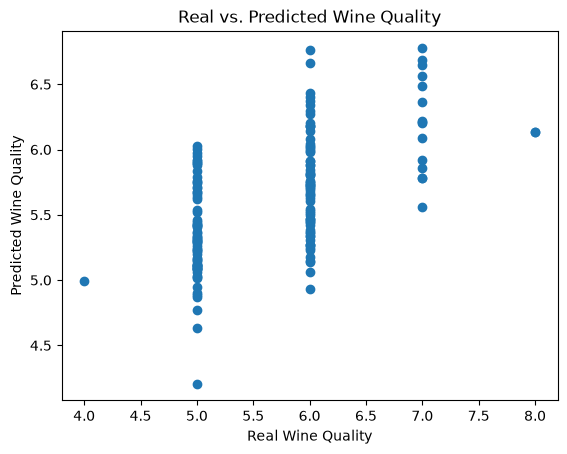


Theta (θ1...θ11): [ 0.035554   -0.20571525 -0.04001263  0.02325971 -0.08536274  0.05358697
 -0.1122051  -0.02440805 -0.07165291  0.15496969  0.30037356]
Intercept (B): 5.634468380820014

With Normalized Target (Y):
R2: 0.3351
MSE: 0.0134


In [13]:

def LR_Pipeline(scaler):
    my_pipeline = Pipeline([
        ('scaler', scaler),
        ('predictor', LinearRegression())
    ])
    return my_pipeline

configs = [
    ("min-max", MinMaxScaler(), 0.1),
    ("standard", StandardScaler(), 0.1),
    ("min-max", MinMaxScaler(), 0.2),
    ("standard", StandardScaler(), 0.2)
]

print(f"{'Scaler':<15} | {'Test Size':<10} | {'R2':<10} | {'MSE':<10}")
print("-" * 55)

for name, scaler, t_size in configs:
    X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=t_size, random_state=20)
    pipe = LR_Pipeline(scaler)
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_te)
    print(f"{name:<15} | {t_size:<10} | {r2_score(y_te, pred):.4f}   | {mean_squared_error(y_te, pred):.4f}")

# 3. Plot for the best configuration (StandardScaler, test_size=0.1)
X_tr, X_te, y_tr, y_te = train_test_split(X, Y, test_size=0.1, random_state=20)
best_pipe = LR_Pipeline(StandardScaler())
best_pipe.fit(X_tr, y_tr)
y_pred = best_pipe.predict(X_te)

plt.scatter(y_te, y_pred)
plt.xlabel("Real Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.title("Real vs. Predicted Wine Quality")
plt.show()

predictor = best_pipe.named_steps['predictor']
theta = predictor.coef_
intercept = predictor.intercept_

print("\nTheta (θ1...θ11):", theta)
print("Intercept (B):", intercept)
y_scaler = MinMaxScaler()
y_tr_norm = y_scaler.fit_transform(y_tr.values.reshape(-1, 1))
y_te_norm = y_scaler.transform(y_te.values.reshape(-1, 1))

norm_pipe = LR_Pipeline(StandardScaler())
norm_pipe.fit(X_tr, y_tr_norm)
y_pred_norm = norm_pipe.predict(X_te)

print("\nWith Normalized Target (Y):")
print(f"R2: {r2_score(y_te_norm, y_pred_norm):.4f}")
print(f"MSE: {mean_squared_error(y_te_norm, y_pred_norm):.4f}")

# I think above one have a bit problem, because of categorized data fed into linear regression.

# EX3

In [14]:
# wines with quality > 6 are "good" (1), the rest are "bad" (0).
y_binary = (Y > 6).astype(int)

In [15]:
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_binary, test_size=0.2, random_state=20)

In [16]:
def Reg_Pipeline(scaler, model):
    my_pipeline = Pipeline([
        ('scaler', scaler),
        ('classifier', model)
    ])
    return my_pipeline

In [17]:
classifier = Reg_Pipeline(StandardScaler(), LogisticRegression())
classifier.fit(X_train_log, y_train_log)
pred = classifier.predict(X_test_log)

In [18]:
pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,

In [19]:
# evaluate the classification performance
accuracy = accuracy_score(y_test_log, pred)
print("Accuracy:", accuracy)
confusion = confusion_matrix(y_test_log, pred)
print("Confusion Matrix:\n", confusion)
classification_report = classification_report(y_test_log, pred)
print("Classification Report:\n", classification_report)

Accuracy: 0.875
Confusion Matrix:
 [[266   8]
 [ 32  14]]
Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       274
           1       0.64      0.30      0.41        46

    accuracy                           0.88       320
   macro avg       0.76      0.64      0.67       320
weighted avg       0.86      0.88      0.86       320



In [20]:
class_counts = y_train_log.value_counts()
total = sum(class_counts)
print(total)
bad_rate = (class_counts[0] * 100) / total
good_rate = (class_counts[1] * 100) / total

print("Checking that")
print(f"Count of 0 (Bad): {class_counts[0]} ({bad_rate:.2f}%)")
print(f"Count of 1 (Good): {class_counts[1]} ({good_rate:.2f}%)")

1279
Checking that
Count of 0 (Bad): 1108 (86.63%)
Count of 1 (Good): 171 (13.37%)


# EX4

In [21]:
from sklearn.naive_bayes import GaussianNB

In [22]:
nb_pipeline = Reg_Pipeline(StandardScaler(), GaussianNB())

In [24]:
nb_pipeline.fit(X_train_log, y_train_log)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](11,)","['fixed acidity','volatile acidity','citric acid',...,'pH','sulphates', 'alcohol']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,11
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [25]:
y_pred_nb = nb_pipeline.predict(X_test_log)

In [29]:
from sklearn.metrics import classification_report
accuracy_nb = accuracy_score(y_test_log, y_pred_nb)
print("Accuracy:", accuracy_nb)
confusion_nb = confusion_matrix(y_test_log, y_pred_nb)
print("confution matrix:")
print(confusion_nb)
classification_rep_nb = classification_report(y_test_log, y_pred_nb)
print("classification report")
print(classification_rep_nb)

Accuracy: 0.815625
confution matrix:
[[230  44]
 [ 15  31]]
classification report
              precision    recall  f1-score   support

           0       0.94      0.84      0.89       274
           1       0.41      0.67      0.51        46

    accuracy                           0.82       320
   macro avg       0.68      0.76      0.70       320
weighted avg       0.86      0.82      0.83       320



# f1 looks good, but matrix isn't looking well ?

# Ex5

In [32]:
from sklearn.metrics import roc_auc_score

# to calculate AUC-ROC, we need the predicted probabilities for the positive class (1), 
# not just the hard {0, 1} predictions. We get this using predict_proba()[:, 1].
prob_log_reg = classifier.predict_proba(X_test_log)[:, 1]
prob_nb = nb_pipeline.predict_proba(X_test_log)[:, 1]

auc_log_reg = roc_auc_score(y_test_log, prob_log_reg)
auc_nb = roc_auc_score(y_test_log, prob_nb)

print(f"Logistic Regression AUC-ROC: {auc_log_reg:.4f}")
print(f"Naive Bayes AUC-ROC: {auc_nb:.4f}")

if auc_log_reg > auc_nb:
    print("\nLog Reg is the better")
elif auc_nb > auc_log_reg:
    print("\nNB is the better")
else:
    print("\nBoth looks same")

Logistic Regression AUC-ROC: 0.8688
Naive Bayes AUC-ROC: 0.8089

Log Reg is the better


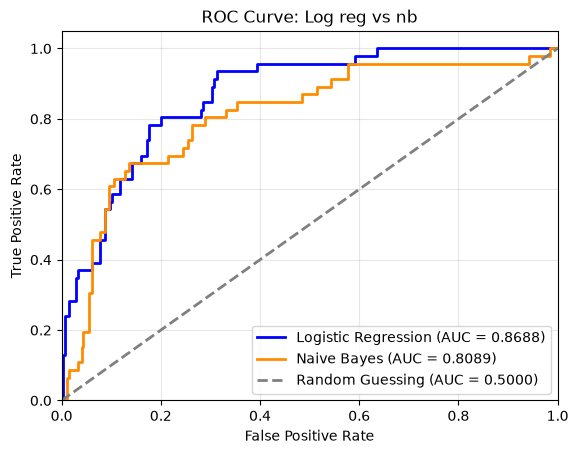

In [35]:
# just trying to visualize
from sklearn.metrics import roc_curve

fpr_log, tpr_log, thresholds_log = roc_curve(y_test_log, prob_log_reg)
fpr_nb, tpr_nb, thresholds_nb = roc_curve(y_test_log, prob_nb)


plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f'Logistic Regression (AUC = {auc_log_reg:.4f})')
plt.plot(fpr_nb, tpr_nb, color='darkorange', lw=2, label=f'Naive Bayes (AUC = {auc_nb:.4f})')

# add the diagonal line representing a random, 50/50 guessing baseline
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guessing (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Log reg vs nb')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# so visually we can confirm that log reg looks better for this data

In [ ]:
link: https://github.com/Rohit-Solanki-6105/ml-learning/blob/main/notebooks/lab2/ex1_to_5.ipynb